# Negotiation Arena: Human and LLM Negotiation Dynamics

This project investigates how different negotiation styles affect multi-agent LLM negotiation outcomes and compares LLM negotiation dynamics with human negotiation patterns from the Negochat corpus.

Research question:

How do cooperative, competitive, and mixed negotiation styles influence agreement rates and negotiation efficiency in LLM-to-LLM bargaining simulations, and how do these dynamics compare to human negotiation patterns?

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.metrics import (
    compute_transition_matrix,
    compute_agreement_rate_by_condition,
    compute_average_turns_by_condition
)

from src.visualization import (
    plot_transition_heatmap,
    plot_outcomes_by_condition,
    plot_average_turns_by_condition
)

In [2]:
human_df = pd.read_csv("../data/processed/human_negotiations.csv")

llm_turns = pd.read_csv("../results/llm_turns_colab.csv")
llm_outcomes = pd.read_csv("../results/llm_outcomes_colab.csv")

print("Human data:", human_df.shape)
print("LLM turns:", llm_turns.shape)
print("LLM outcomes:", llm_outcomes.shape)

Human data: (4993, 8)
LLM turns: (254, 9)
LLM outcomes: (27, 5)


In [3]:
human_df["act"].value_counts()

act
Offer     2996
Reject     790
Accept     547
Other      394
Greet      135
Query      113
Quit        18
Name: count, dtype: int64

In [4]:
human_df["issue"].value_counts()

issue
Working Hours              865
Salary                     852
Job Description            685
Leased Car                 573
Pension Fund               406
Promotion Possibilities    274
Offer                       64
Name: count, dtype: int64

In [5]:
human_df.groupby(["role", "act"]).size().unstack(fill_value=0)

act,Accept,Greet,Offer,Other,Query,Quit,Reject
role,,,,,,,
Candidate,298,105,1704,284,34,0,542
Employer,249,30,1292,110,79,18,248


In [6]:
human_dialogue_lengths = human_df.groupby("dialogue_id")["turn_id"].nunique()
human_dialogue_lengths.describe()

count    105.000000
mean      34.514286
std       16.407734
min        8.000000
25%       23.000000
50%       30.000000
75%       44.000000
max      103.000000
Name: turn_id, dtype: float64

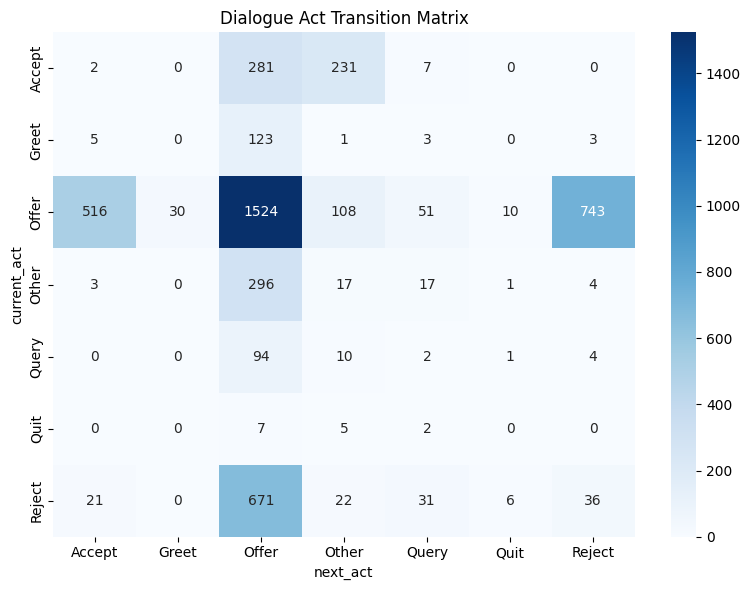

In [7]:
human_transition_matrix = compute_transition_matrix(human_df)
plot_transition_heatmap(human_transition_matrix)

### LLM


In [8]:
llm_outcomes["outcome"].value_counts()

outcome
Timeout      15
Agreement     7
Failure       5
Name: count, dtype: int64

In [9]:
llm_outcomes.groupby("condition")["outcome"].value_counts()

condition    outcome  
competitive  Timeout      5
             Failure      3
             Agreement    1
cooperative  Agreement    4
             Timeout      4
             Failure      1
mixed        Timeout      6
             Agreement    2
             Failure      1
Name: count, dtype: int64

In [10]:
llm_outcomes.groupby("condition")["n_turns"].mean()

condition
competitive    10.111111
cooperative     8.888889
mixed           9.222222
Name: n_turns, dtype: float64

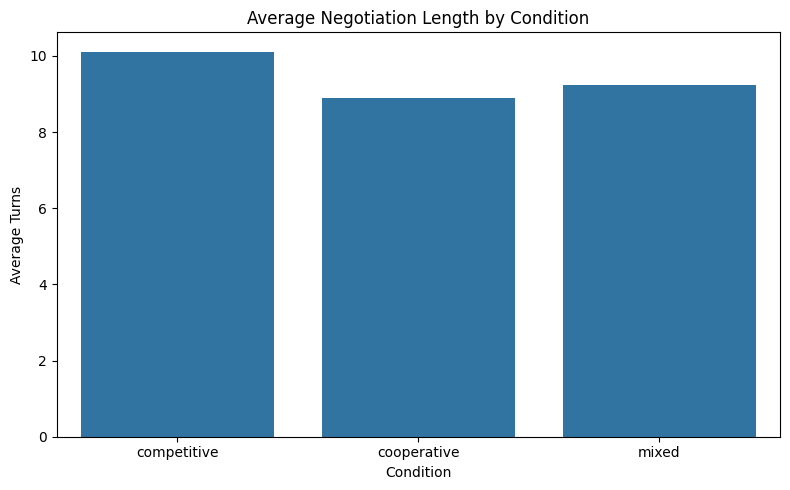

In [11]:
plot_average_turns_by_condition(llm_outcomes)

## SALARY AND HOURS ANALYSIS 

In [12]:
llm_turns.groupby("condition")["salary_offer"].mean()

condition
competitive    117704.352941
cooperative     92944.912281
mixed           96130.709091
Name: salary_offer, dtype: float64

In [13]:
llm_turns.groupby("condition")["hours_offer"].mean()

condition
competitive    8.188889
cooperative    8.392157
mixed          9.875000
Name: hours_offer, dtype: float64

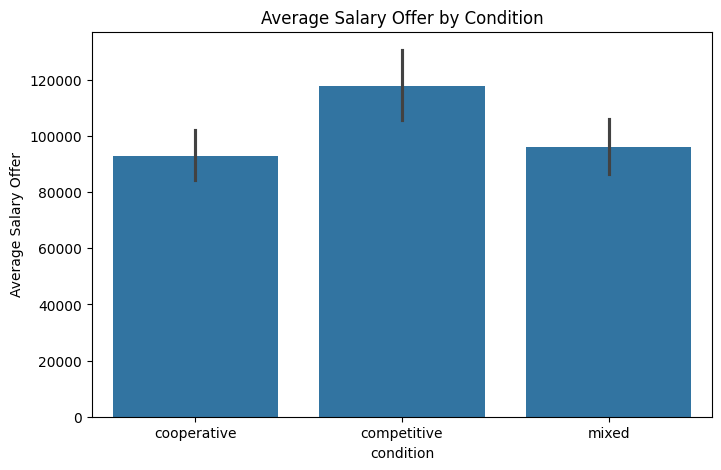

In [14]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=llm_turns,
    x="condition",
    y="salary_offer",
    estimator="mean"
)
plt.title("Average Salary Offer by Condition")
plt.ylabel("Average Salary Offer")
plt.show()

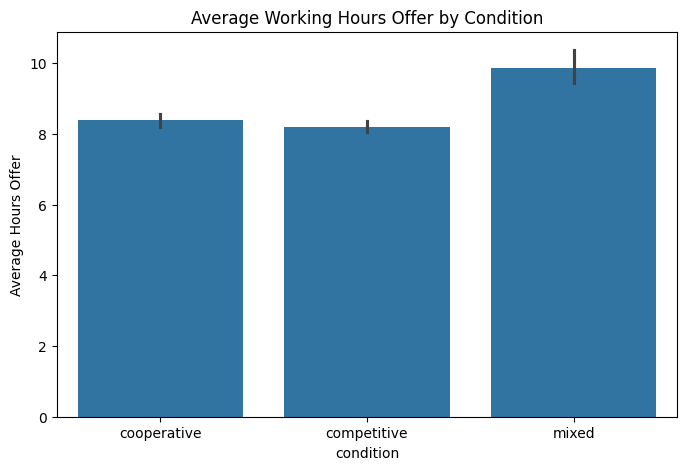

In [15]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=llm_turns,
    x="condition",
    y="hours_offer",
    estimator="mean"
)
plt.title("Average Working Hours Offer by Condition")
plt.ylabel("Average Hours Offer")
plt.show()

In [16]:
human_avg_turns = human_df.groupby("dialogue_id")["turn_id"].nunique().mean()
llm_avg_turns = llm_outcomes["n_turns"].mean()

comparison_turns = pd.DataFrame({
    "source": ["Human Negochat", "LLM Agents"],
    "avg_turns": [human_avg_turns, llm_avg_turns]
})

comparison_turns

,source,avg_turns
0,Human Negochat,34.514286
1,LLM Agents,9.407407


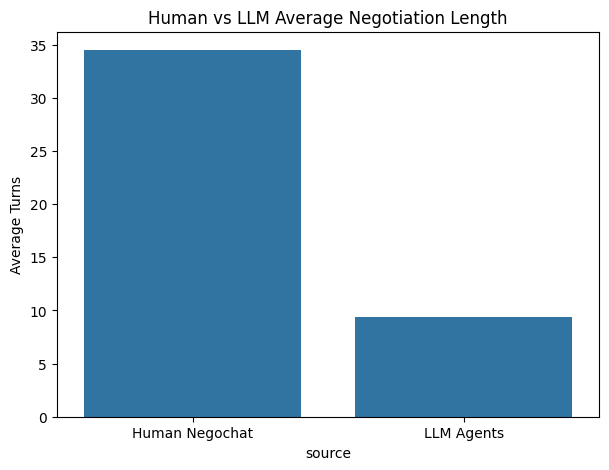

In [17]:
plt.figure(figsize=(7, 5))
sns.barplot(
    data=comparison_turns,
    x="source",
    y="avg_turns"
)
plt.title("Human vs LLM Average Negotiation Length")
plt.ylabel("Average Turns")
plt.show()

Human negotiations are substantially longer than LLM simulations. This is expected because Negochat contains full multi-issue job negotiations, while LLM simulations were constrained to salary and working hours with a maximum number of turns. However, the comparison is useful to show that LLM agents tend to converge faster and produce more compressed negotiation dynamics. Only under constraints otherwise they would reach no end 

The results suggest that negotiation style influences LLM agent behavior. Cooperative agents tend to reach agreements faster, while competitive and mixed configurations produce longer interactions and more negotiation friction.

Compared to human negotiations, LLM negotiations are shorter and more structured. Human negotiators show richer multi-issue dynamics and more varied dialogue act transitions, while LLM agents often follow the imposed structured format and focus on the explicitly defined negotiation variables.

A limitation of the LLM setup is that models sometimes produce inconsistent structured outputs or fail to explicitly accept valid offers. For this reason, external parsing and rule-based validation were used to evaluate whether an agreement was valid.